# Notebook 03 — SSIM Baseline

## Objective

This notebook investigates whether Structural Similarity Index Measure (SSIM) can improve change detection compared to simple pixel differencing.

Unlike raw pixel difference, SSIM compares local image structure and is expected to be more robust to illumination variation and small local noise.

The pipeline consists of:

1. Computing an SSIM similarity map between before and after images.
2. Converting similarity into a change map.
3. Applying thresholding and morphology.
4. Evaluating the predicted change mask against ground truth.

# 1. Imports

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from skimage.metrics import structural_similarity as ssim

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

# 2. Paths

In [4]:
DATA_PATH = "../data/raw"

TRAIN_PATH = os.path.join(DATA_PATH, "train")
VAL_PATH = os.path.join(DATA_PATH, "val")
TEST_PATH = os.path.join(DATA_PATH, "test")

# 3. Test on one sample first

In [5]:
sample_name = sorted(
    os.listdir(
        os.path.join(TRAIN_PATH, "A")
    )
)[0]

sample_name

'train_1.png'

Load images

In [6]:
before = cv2.imread(
    os.path.join(
        TRAIN_PATH,
        "A",
        sample_name
    )
)

after = cv2.imread(
    os.path.join(
        TRAIN_PATH,
        "B",
        sample_name
    )
)

label = cv2.imread(
    os.path.join(
        TRAIN_PATH,
        "label",
        sample_name
    ),
    cv2.IMREAD_GRAYSCALE
)

Convert RGB

In [7]:
before = cv2.cvtColor(
    before,
    cv2.COLOR_BGR2RGB
)

after = cv2.cvtColor(
    after,
    cv2.COLOR_BGR2RGB
)

Grayscale

In [8]:
before_gray = cv2.cvtColor(
    before,
    cv2.COLOR_RGB2GRAY
)

after_gray = cv2.cvtColor(
    after,
    cv2.COLOR_RGB2GRAY
)

Blur

In [9]:
before_blur = cv2.GaussianBlur(
    before_gray,
    (5,5),
    0
)

after_blur = cv2.GaussianBlur(
    after_gray,
    (5,5),
    0
)

# 4. Compute SSIM

In [10]:
score, diff = ssim(
    before_blur,
    after_blur,
    full=True
)

print("SSIM similarity:", score)

SSIM similarity: 0.324117172161267


In [11]:
diff = (
    1 - diff
)
diff = (
    diff * 255
).astype(np.uint8)

# 5. Visualize SSIM map

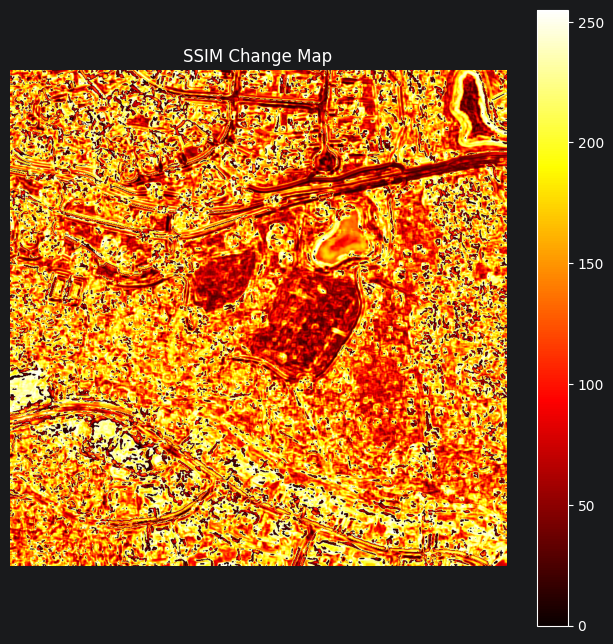

In [12]:
plt.figure(figsize=(8,8))

plt.imshow(
    diff,
    cmap="hot"
)

plt.title("SSIM Change Map")
plt.colorbar()
plt.axis("off")

plt.show()

# 6. Thresholding

In [13]:
_, pred_mask = cv2.threshold(
    diff,
    0,
    255,
    cv2.THRESH_BINARY
    + cv2.THRESH_OTSU
)

pred_mask = pred_mask // 255

# 7. Morphology

In [14]:
kernel = np.ones((3,3), np.uint8)

pred_mask = cv2.morphologyEx(
    pred_mask.astype(np.uint8),
    cv2.MORPH_OPEN,
    kernel
)

pred_mask = cv2.morphologyEx(
    pred_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# 8. Visual Comparison

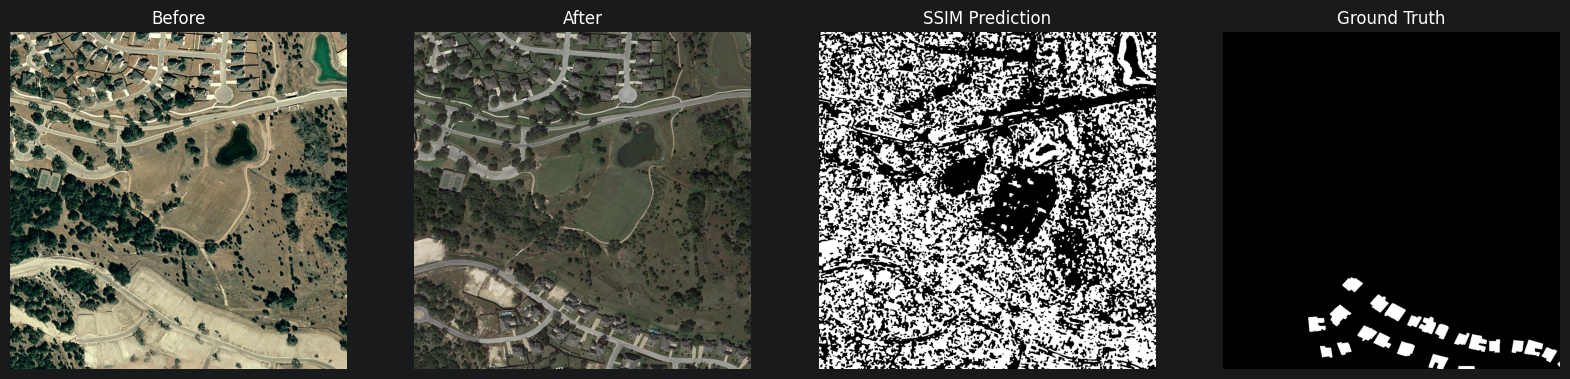

In [15]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(20,6)
)

ax[0].imshow(before)
ax[0].set_title("Before")

ax[1].imshow(after)
ax[1].set_title("After")

ax[2].imshow(
    pred_mask,
    cmap="gray"
)
ax[2].set_title("SSIM Prediction")

ax[3].imshow(
    label,
    cmap="gray"
)
ax[3].set_title("Ground Truth")

for a in ax:
    a.axis("off")

plt.show()

# 9. Metrics

In [16]:
label_binary = (
    label > 0
).astype(np.uint8)

y_true = label_binary.flatten()
y_pred = pred_mask.flatten()

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

iou = jaccard_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("IoU:", iou)

Precision: 0.04258486701545245
Recall: 0.7432948960909646
F1: 0.08055459827131872
IoU: 0.041967642423571955


## Conclusions

The SSIM-based baseline did not significantly improve performance over simple pixel differencing.

Although the SSIM change map highlighted some building regions more clearly, it still produced many false positives. The method remained sensitive to:

- roof textures,
- shadows,
- vegetation,
- roads,
- local structural differences unrelated to building change.

The results suggest that classical image similarity methods are insufficient for this dataset.

This motivates moving from rule-based computer vision toward supervised machine learning methods that can learn discriminative patterns from labeled examples.